# Clasificación Básica: Predecir una imagen de moda

Esta Guia entrena un modelo de red neuronal para clasificar imágenes de ropa, como tennis y camisetas.

Esta Guia usa [tf.keras](https://www.tensorflow.org/guide/keras), un API de alto nivel para construir y entrenar modelos en Tensorflow.

## Importar el set de datos de moda de MNIST

Esta guia usa el set de datos de [Fashion MNIST](https://github.com/zalandoresearch/fashion-mnist)
que contiene mas de 70,000 imágenes en 10 categorias. Las imágenes muestran articulos individuales de ropa a una resolucion baja (28 por 28 pixeles) como se ve aca:

<table>
  <tr><td>
    <img src="https://tensorflow.org/images/fashion-mnist-sprite.png"
         alt="Fashion MNIST sprite"  width="600">
  </td></tr>
  <tr><td align="center">
    <b>Figure 1.</b> <a href="https://github.com/zalandoresearch/fashion-mnist">Fashion-MNIST samples</a> (by Zalando, MIT License).<br/>&nbsp;
  </td></tr>
</table>

Para importar y cargar el set de datos de MNIST directamente de TensorFlow:

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow import keras

In [2]:
dataset = keras.datasets.fashion_mnist
dataset.load_data()

((array([[[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          ...,
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0]],
  
         [[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          ...,
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0]],
  
         [[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          ...,
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0]],
  
         ...,
  
         [[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          ...,
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0]],
  
         [[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0

In [3]:
len(dataset.load_data()[0])

2

In [4]:
(X_train, y_train), (X_test, y_test) = dataset.load_data()

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(60000, 28, 28)
(10000, 28, 28)
(60000,)
(10000,)


La *class* de ropa que la imagen representa.

<table>
  <tr>
    <th>Label</th>
    <th>Class</th>
  </tr>
  <tr>
    <td>0</td>
    <td>T-shirt/top</td>
  </tr>
  <tr>
    <td>1</td>
    <td>Trouser</td>
  </tr>
    <tr>
    <td>2</td>
    <td>Pullover</td>
  </tr>
    <tr>
    <td>3</td>
    <td>Dress</td>
  </tr>
    <tr>
    <td>4</td>
    <td>Coat</td>
  </tr>
    <tr>
    <td>5</td>
    <td>Sandal</td>
  </tr>
    <tr>
    <td>6</td>
    <td>Shirt</td>
  </tr>
    <tr>
    <td>7</td>
    <td>Sneaker</td>
  </tr>
    <tr>
    <td>8</td>
    <td>Bag</td>
  </tr>
    <tr>
    <td>9</td>
    <td>Ankle boot</td>
  </tr>
</table>

Cada imagen es mapeada a una unica etiqueta. Ya que los *Class names* no estan incluidos en el dataset. Los guardamos en la siguiente lista:

In [5]:
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
len(class_names)

10

In [6]:
y_train

array([9, 0, 0, ..., 3, 0, 5], shape=(60000,), dtype=uint8)

## Explore el set de datos

* ¿Cuántas imágenes hay en train?
* ¿Y en test?
* ¿De cuántos pixels se compone cada imagen?
* ¿Cuáles son los valores de los labels?

In [7]:
X_train.shape[0]

60000

In [8]:
X_test.shape[0]

10000

In [9]:
# Multiplicamos el ancho por el alto de la imagen para obtener el total de píxeles.
# Si X_train.shape es (60000, 28, 28):
# X_train.shape[1] es la altura (28)
# X_train.shape[2] es la anchura (28)
# El resultado (784) es la cantidad de neuronas necesarias si decidieras aplanar la imagen manualmente.

input_dim = X_train.shape[1] * X_train.shape[2] 


In [10]:
# Convertimos el array de etiquetas 'y_train' en una Serie de Pandas.
# El método .value_counts() cuenta cuántas veces aparece cada clase (ej. cuántos 0s, 1s, etc.).
# Esto sirve para comprobar si el dataset está balanceado o si hay más ejemplos de una categoría que de otra.

distribucion_clases = pd.Series(y_train).value_counts()


In [11]:
# Convertimos el array de etiquetas de prueba 'y_test' en una Serie de Pandas.
# .value_counts() cuenta cuántas muestras hay de cada clase en el set de test.
# Es vital para confirmar que el set de evaluación también es representativo y equilibrado.

conteo_test = pd.Series(y_test).value_counts()


## Pre-procese el set de datos

Inspecciona y representa la primera imagen del dataset de train. Para ello, utiliza la función `imshow` de matplotlib.

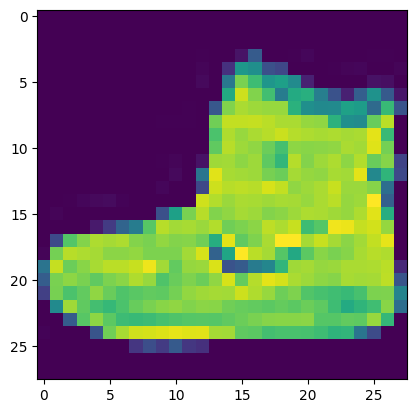

In [12]:
plt.imshow(X_train[0], cmap="viridis")

Escala los conjuntos de train y test para que vayan del 0 al 1. No hace falta usar ninguna librería. Con realizar una división en cada conjunto será suficiente.

In [13]:
X_train.min()

np.uint8(0)

In [14]:
X_train.max()

np.uint8(255)

In [15]:
X_train = X_train/255
X_test = X_test/255

In [16]:
X_train.min()

np.float64(0.0)

In [17]:
X_train.max()

np.float64(1.0)

Para verificar que el set de datos está en el formato adecuado y que están listos para construir y entrenar la red, vamos a desplegar las primeras 25 imágenes del *training set* y despleguemos el nombre de cada clase debajo de cada imagen.

In [18]:
class_names

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

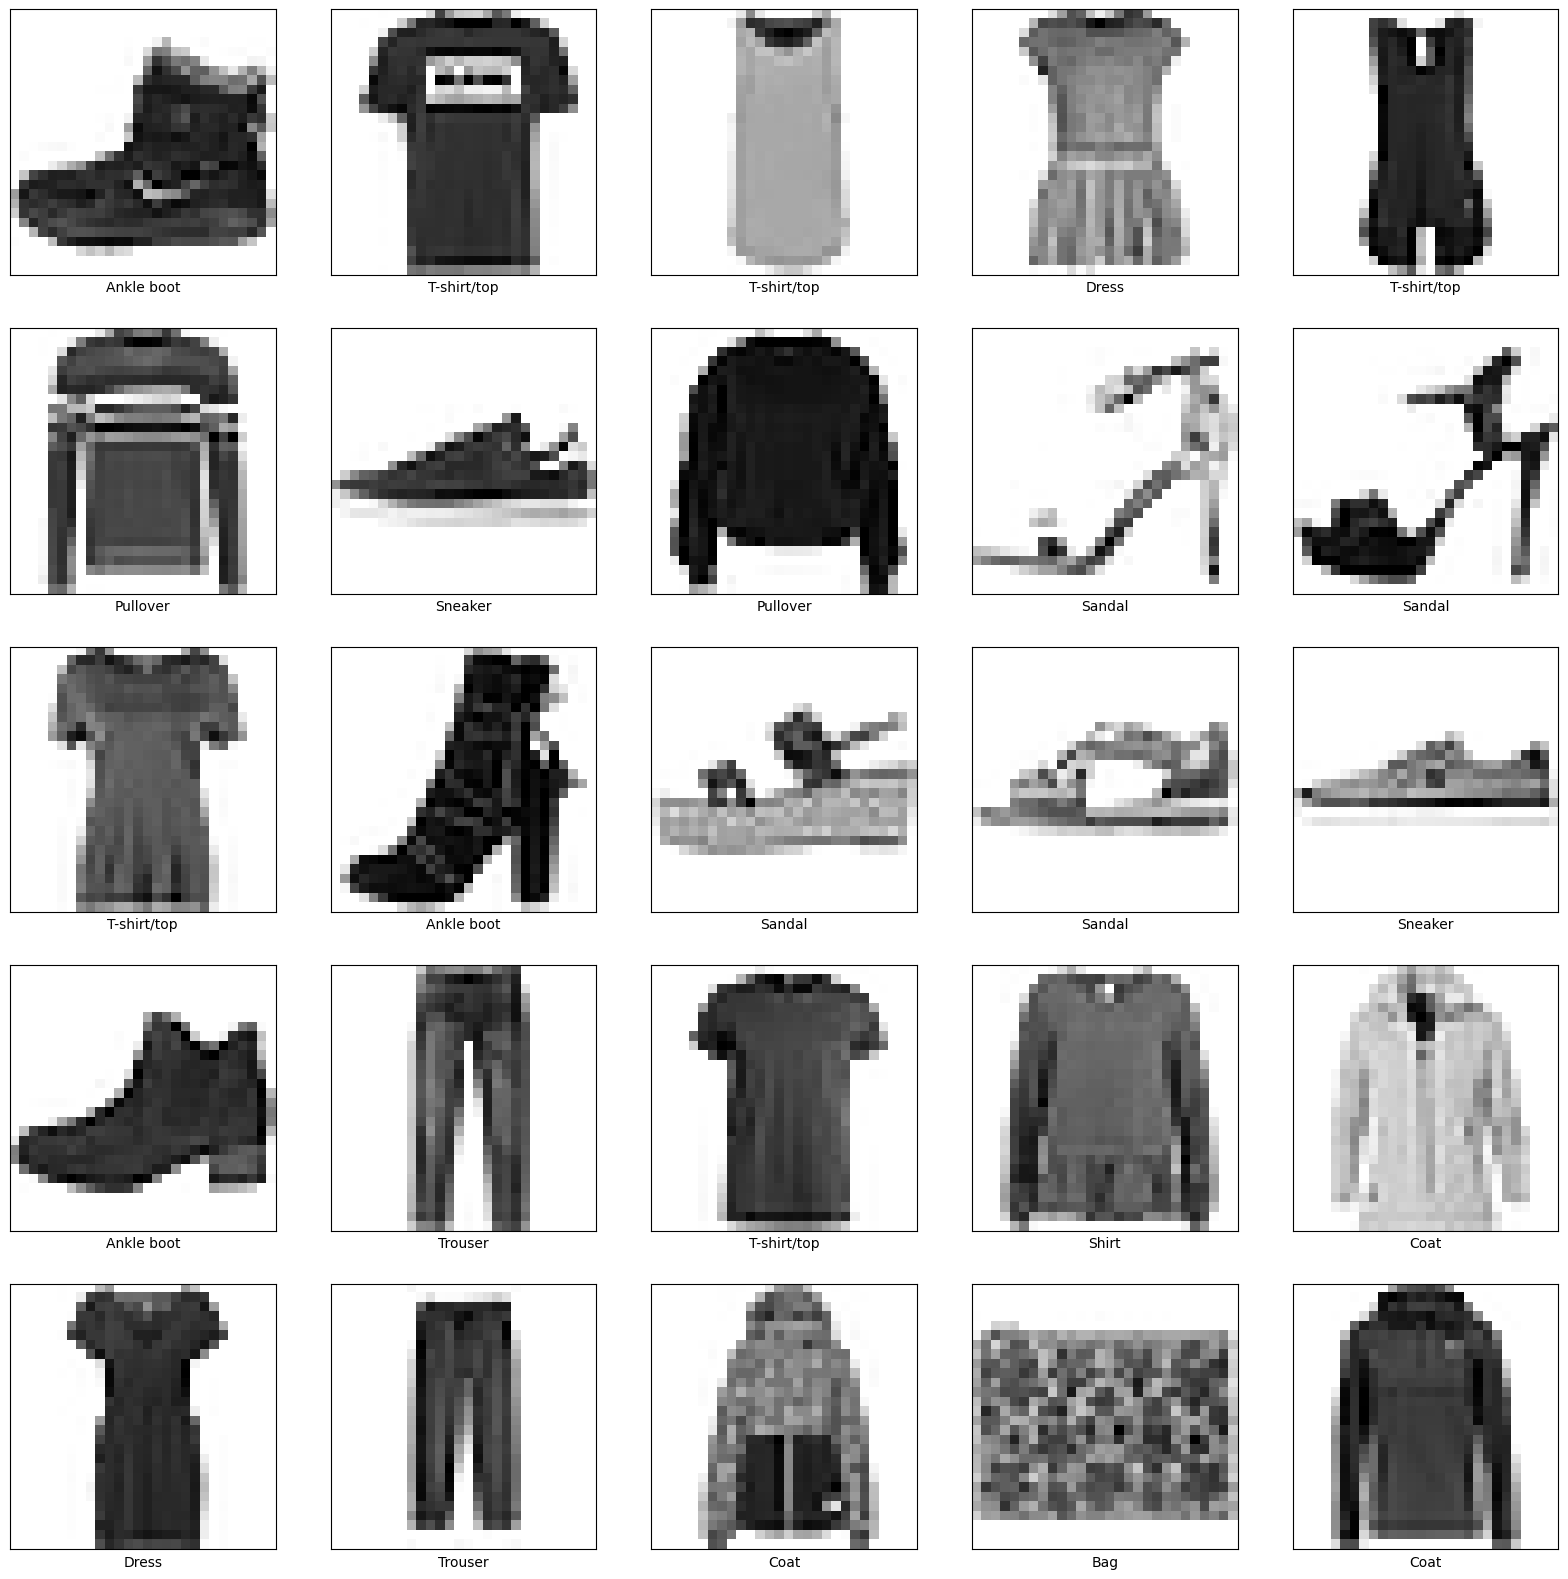

In [19]:
# Crea un lienzo (figura) de gran tamaño, 20x20 pulgadas, para que las imágenes se vean claras
plt.figure(figsize=(20,20))

# Bucle para recorrer las primeras 25 imágenes del set de entrenamiento
for i in range(25):
    # Crea una cuadrícula de 5 filas y 5 columnas. i+1 indica la posición actual (de 1 a 25)
    plt.subplot(5,5, i+1)
    
    # Dibuja la imagen en la posición 'i' usando un mapa de color blanco y negro
    plt.imshow(X_train[i], cmap="binary")
    
    # Quita las marcas de los ejes (opcional, para que quede más limpio)
    plt.xticks([])
    plt.yticks([])
    
    # Usa el valor numérico de la etiqueta y_train[i] para buscar el nombre de la clase
    # en la lista 'class_names' y lo pone como texto debajo de la imagen
    plt.xlabel(class_names[y_train[i]])


## Construir el Modelo

Construir la red neuronal requiere configurar las capas del modelo y luego compilar el modelo.

### Configurar las Capas
Construye todas las capas del modelo.

In [20]:
from keras import Sequential, Input
from keras.layers import Flatten, Dense
# Definimos el modelo como una secuencia lineal de capas
model = Sequential([
    # Especificamos el tamaño de entrada (imágenes de 28x28 píxeles)
    Input(shape=(28, 28)),         
    
    # Convertimos la matriz de 28x28 en un vector plano de 784 neuronas
    Flatten(),                     
    
    # Capa intermedia con 128 neuronas y activación ReLU para aprender patrones complejos
    Dense(128, activation='relu'), 
    
    # Capa de salida con 10 neuronas (una por clase) y Softmax para obtener probabilidades
    Dense(10, activation='softmax')
])


### Compila el modelo

Antes de que el modelo este listo para entrenar , se necesitan algunas configuraciones más. Estas son agregadas durante el paso de compilacion del modelo:

* *Loss function* —Esto mide que tan exacto es el modelo durante el entrenamiento. Quiere minimizar esta función para dirigir el modelo en la dirección adecuada.
* *Optimizer* — Esto es cómo el modelo aprende basado en el set de datos que ve y la función de pérdida.
* *Metrics* — Se usan para monitorear los pasos de entrenamiento y de pruebas.


Como es un problema de clasificación multiclase, tendrás que usar `sparse_categorical_crossentropy` como función de coste. En cuanto a las métricas, usa simplemente `accuracy`.

In [21]:
# Configuramos el proceso de aprendizaje del modelo
model.compile(
    # Usamos el optimizador Descenso de Gradiente Estocástico (SGD) para ajustar los pesos
    optimizer = keras.optimizers.SGD(),
    
    # Función de pérdida para etiquetas que son números enteros (0, 1, 2...)
    loss = keras.losses.SparseCategoricalCrossentropy(),
    
    # Métrica para rastrear el porcentaje de predicciones correctas durante el entrenamiento
    metrics = [keras.metrics.SparseCategoricalAccuracy()]
)


In [22]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

## Entrenar el Modelo
Empieza entrenándolo con 10 epochs. Prueba con más

In [23]:
history = model.fit(X_train, y_train, epochs=10, validation_split=0.1)

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.7741 - sparse_categorical_accuracy: 0.7554 - val_loss: 0.5547 - val_sparse_categorical_accuracy: 0.8170
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.5242 - sparse_categorical_accuracy: 0.8234 - val_loss: 0.6112 - val_sparse_categorical_accuracy: 0.7708
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.4779 - sparse_categorical_accuracy: 0.8366 - val_loss: 0.4557 - val_sparse_categorical_accuracy: 0.8375
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.4516 - sparse_categorical_accuracy: 0.8446 - val_loss: 0.4487 - val_sparse_categorical_accuracy: 0.8427
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.4328 - sparse_categorical_accuracy: 0.8507 - val_loss: 0.4298 - val_sparse_categorical_accuracy: 0.8492
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.4189 - sparse_categorical_accuracy: 0.8557 - val_loss: 0.4242 - val_sparse_categorical_accuracy:

In [28]:
model_2 = keras.Sequential([
    keras.layers.Flatten(input_shape=(28,28)),
    keras.layers.Dense(256,activation="relu"),
    keras.layers.Dense(256,activation="relu"),
    keras.layers.Dense(64,activation="relu"),
    keras.layers.Dense(10, activation="softmax")
])

model_2.compile(optimizer="sgd",
              loss = "sparse_categorical_crossentropy",
              metrics = ['accuracy'])

c:\Users\Eneko\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [29]:
history_2 = model_2.fit(X_train, y_train, epochs=50, validation_split=0.1, callbacks=[keras.callbacks.EarlyStopping(patience=5)])

Epoch 1/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7618 - loss: 0.7092 - val_accuracy: 0.8180 - val_loss: 0.5241
Epoch 2/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8309 - loss: 0.4797 - val_accuracy: 0.7900 - val_loss: 0.5543
Epoch 3/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8482 - loss: 0.4306 - val_accuracy: 0.8345 - val_loss: 0.4442
Epoch 4/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8583 - loss: 0.4016 - val_accuracy: 0.8545 - val_loss: 0.3945
Epoch 5/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8649 - loss: 0.3782 - val_accuracy: 0.8625 - val_loss: 0.3884
Epoch 6/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8716 - loss: 0.3602 - val_accuracy: 0.8667 - val_loss: 0.3651
Epoch 7/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8757 - loss: 0.3453 - val_accuracy: 0.8703 - val_loss: 0.3648
Epoch 8/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8794 - loss: 0.3337 - 

In [30]:
results = model.evaluate(X_test, y_test)
print("test loss, test acc:", results)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3690 - sparse_categorical_accuracy: 0.8697
test loss, test acc: [0.36896634101867676, 0.869700014591217]


In [34]:
# Evaluar el modelo 2 con los datos de test
results_2 = model_2.evaluate(X_test, y_test)

print("Resultados Modelo 2 (loss, metrics):", results_2)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8800 - loss: 0.3541
Resultados Modelo 2 (loss, metrics): [0.3541014492511749, 0.8799999952316284]


## Evaluar Accuracy
Prueba el rendimiento del modelo con los datos de test

In [91]:
model.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4153 - sparse_categorical_accuracy: 0.8541


[0.4152877926826477, 0.8540999889373779]

In [35]:
# Evaluar el segundo modelo
results_2 = model_2.evaluate(X_test, y_test)

# Imprimir los resultados (Pérdida y métricas de test)
print("Resultados Modelo 2 (test loss, test metrics):", results_2)


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8800 - loss: 0.3541
Resultados Modelo 2 (test loss, test metrics): [0.3541014492511749, 0.8799999952316284]


## Hacer predicciones

Con el modelo entrenado puedes usarlo para hacer predicciones sobre imagenes.

In [37]:
# El modelo genera predicciones para todo el conjunto de prueba (X_test).
# y_pred contendrá una matriz de probabilidades (una lista de 10 números por cada imagen).
y_pred = model_2.predict(X_test)

# Mostramos el contenido de las predicciones.
# Cada fila muestra qué tan seguro está el modelo de que la imagen pertenece a cada clase (0-9).
y_pred


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


array([[1.4995752e-05, 3.1528711e-07, 2.5923532e-07, ..., 3.3599029e-03,
        2.0602256e-05, 9.9654949e-01],
       [2.6463649e-05, 3.0857723e-11, 9.9987912e-01, ..., 2.3556070e-13,
        4.5126713e-10, 1.2376517e-12],
       [3.1239164e-08, 1.0000000e+00, 6.6096885e-11, ..., 6.7063755e-12,
        5.1576750e-11, 1.9417985e-11],
       ...,
       [4.3724111e-05, 2.8651954e-09, 1.0214680e-05, ..., 1.4342137e-06,
        9.9984562e-01, 1.6341817e-08],
       [1.1301821e-07, 9.9999535e-01, 9.9026396e-09, ..., 1.9342293e-08,
        1.8745610e-09, 3.7004465e-08],
       [1.1558875e-05, 2.5947727e-06, 3.6117639e-05, ..., 1.2150910e-03,
        2.0048665e-04, 4.5002380e-06]], shape=(10000, 10), dtype=float32)

In [38]:
# Utilizamos np.argmax para encontrar el índice del valor más alto en cada fila.
# Como y_pred tiene 10 probabilidades por imagen, axis=1 busca el máximo en la horizontal.
# Esto convierte las probabilidades (ej: 0.001, 0.98, 0.01...) en el número de clase final (ej: 1).
y_pred_labels = np.argmax(y_pred, axis=1)

# Mostramos el array con las etiquetas predichas (números del 0 al 9).
# Ahora es un formato comparable directamente con las etiquetas reales de y_test.
y_pred_labels


array([9, 2, 1, ..., 8, 1, 5], shape=(10000,))

El modelo ha predicho la etiqueta para cada imagen en el set de datos de *test* (prueba). Miremos la primera prediccion:

In [39]:
y_pred[0]

array([1.4995752e-05, 3.1528711e-07, 2.5923532e-07, 1.0660365e-07,
       2.2049012e-07, 5.3772928e-05, 2.3883496e-07, 3.3599029e-03,
       2.0602256e-05, 9.9654949e-01], dtype=float32)

In [40]:
y_pred_labels[0]

np.int64(9)

In [41]:
class_names[y_pred_labels[0]]

'Ankle boot'

*Una* prediccion es un array de 10 numeros. Estos representan el nivel de "confianza" del modelo sobre las imagenes de cada uno de los 10 articulos de moda/ropa. Puedes revisar cual tiene el nivel mas alto de confianza:

In [42]:
def plot_image(i, predictions_array, true_label, img):
  predictions_array, true_label, img = predictions_array, true_label[i], img[i]
  plt.grid(False)
  plt.xticks([])
  plt.yticks([])

  plt.imshow(img, cmap=plt.cm.binary)

  predicted_label = np.argmax(predictions_array)
  if predicted_label == true_label:
    color = 'blue'
  else:
    color = 'red'

  plt.xlabel("{} {:2.0f}% ({})".format(class_names[predicted_label],
                                100*np.max(predictions_array),
                                class_names[true_label]),
                                color=color)

def plot_value_array(i, predictions_array, true_label):
  predictions_array, true_label = predictions_array, true_label[i]
  plt.grid(False)
  plt.xticks(range(10))
  plt.yticks([])
  thisplot = plt.bar(range(10), predictions_array, color="#777777")
  plt.ylim([0, 1])
  predicted_label = np.argmax(predictions_array)

  thisplot[predicted_label].set_color('red')
  thisplot[true_label].set_color('blue')

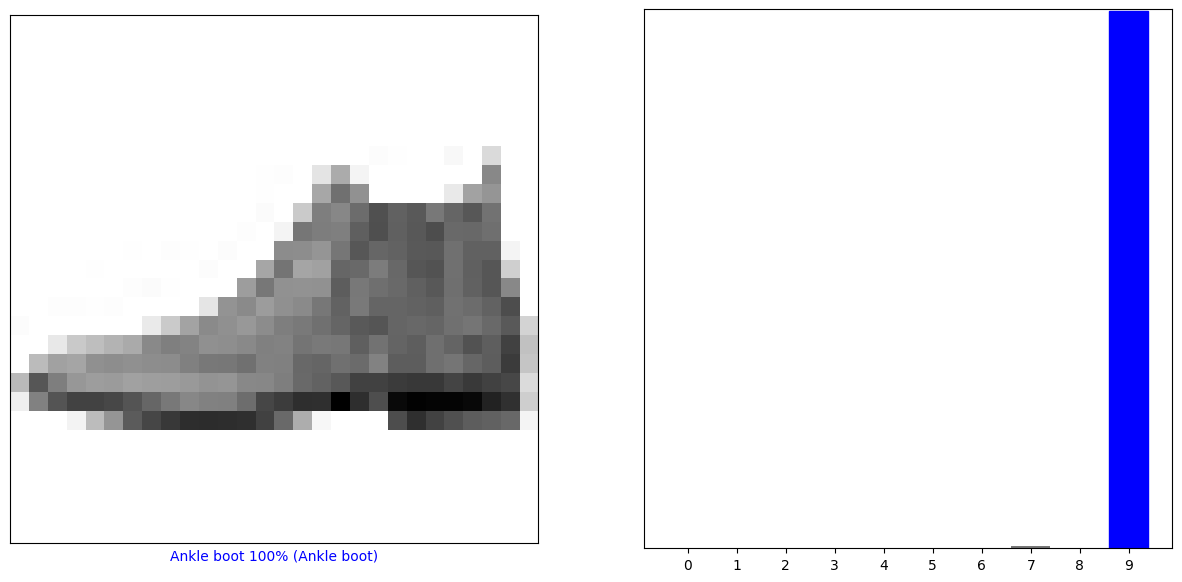

In [43]:
i = 0
plt.figure(figsize=(15,7))
plt.subplot(1,2,1)
plot_image(i, y_pred[i], y_test, X_test)
plt.subplot(1,2,2)
plot_value_array(i, y_pred[i], y_test)

Entonces, el modelo tiene mayor confianza que esta imagen es un bota de tobillo "ankle boot" o `class_names[9]`. Examinando las etiquetas de *test* o de pruebas muestra que esta clasificación es correcta:

**Grafica** esto para poder ver todo el set de la prediccion de las 10 clases.

Miremos la imagen [0], sus predicciones y el array de predicciones. Las etiquetas de predicción correctas estan en azul y las incorrectas están en rojo. El número entrega el porcentaje (sobre 100) para la etiqueta predicha.

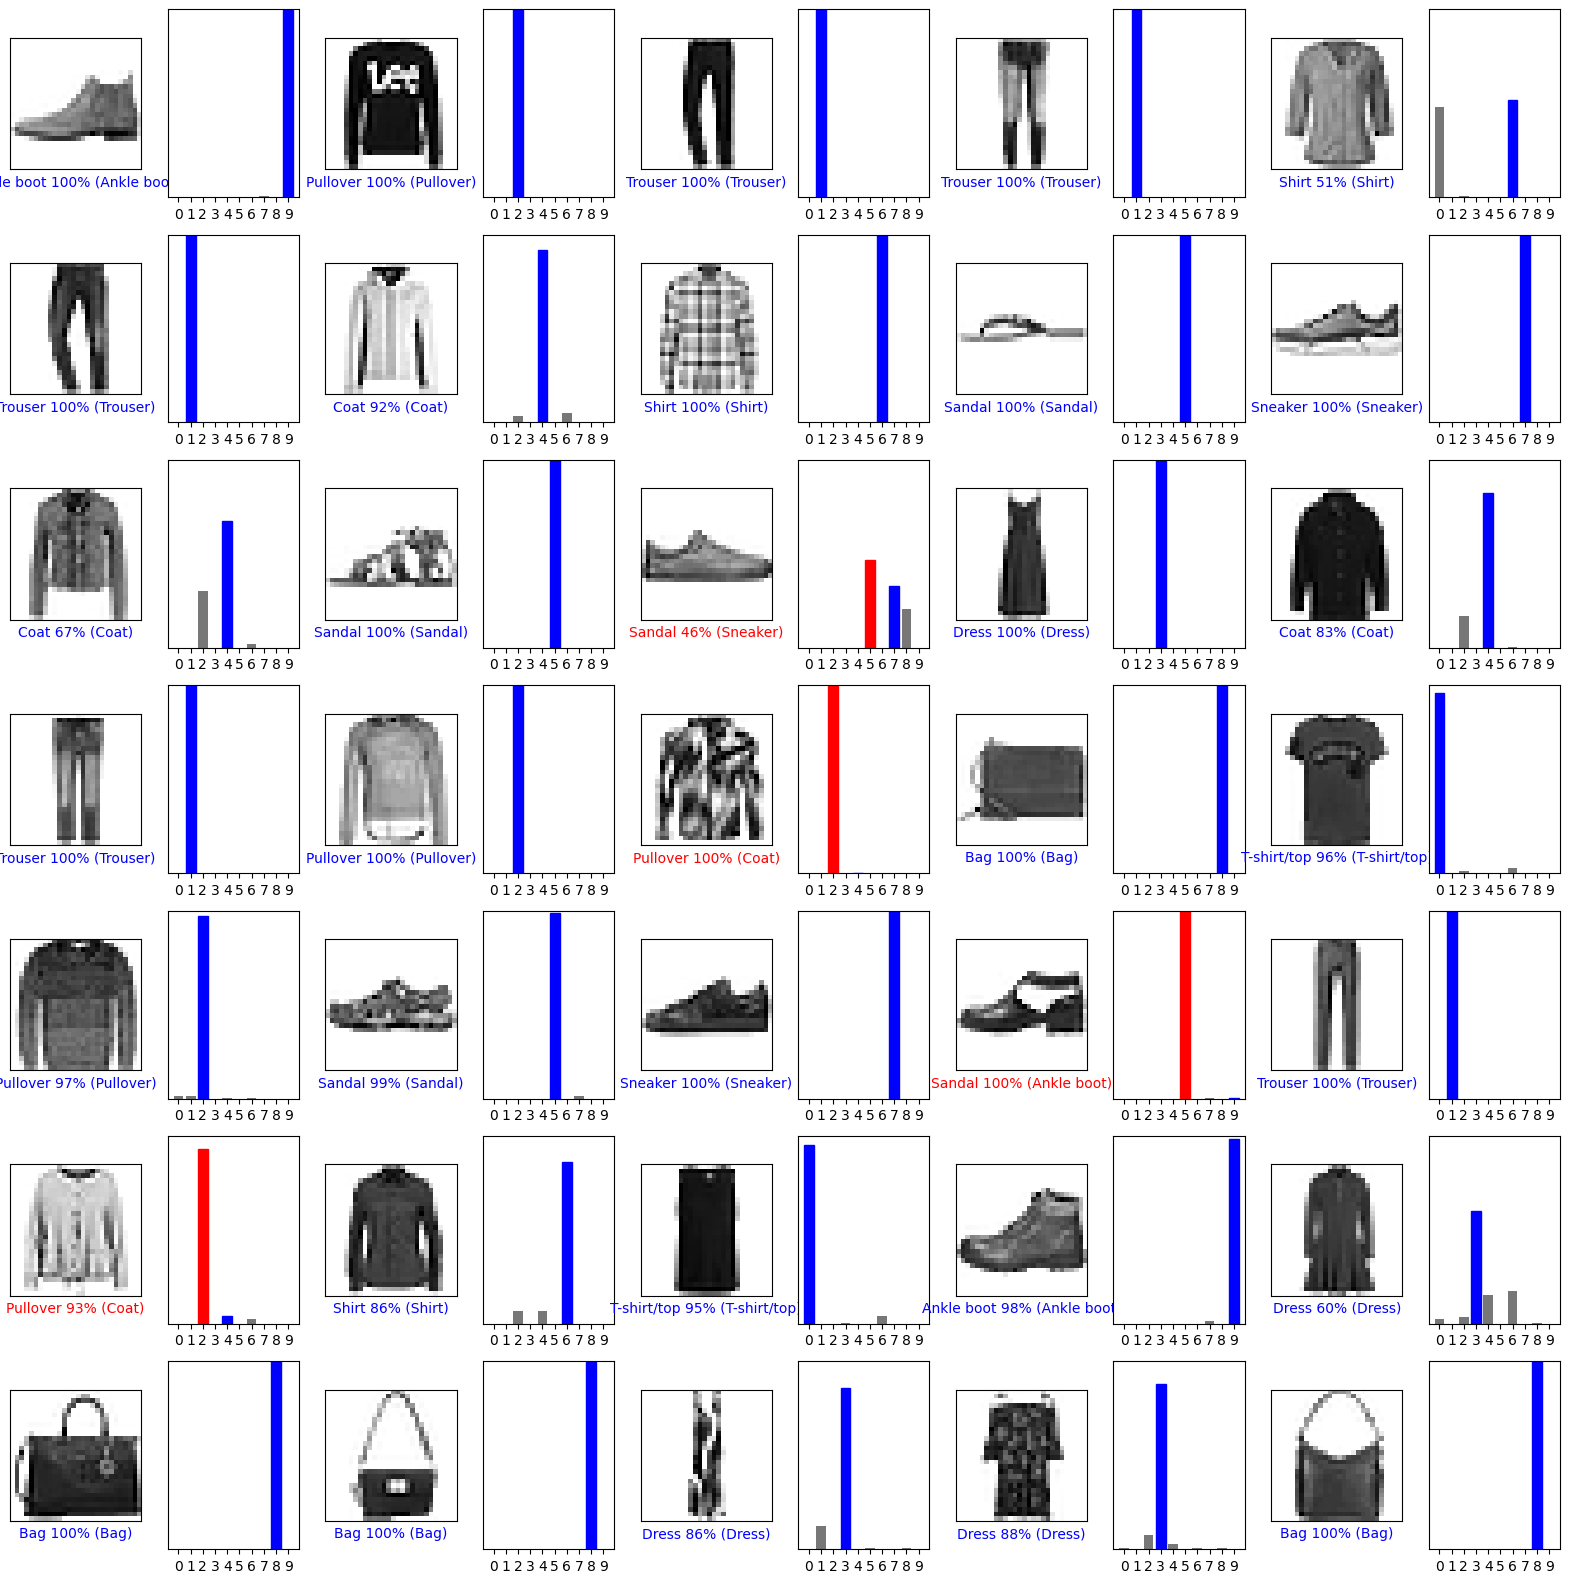

In [44]:
# Definimos las dimensiones de la cuadrícula: 7 filas y 5 columnas
n_rows = 7
n_cols = 5
# Calculamos el número total de imágenes a mostrar (35 en este caso)
n_img = n_rows * n_cols

# Creamos el lienzo con un tamaño de 20x20 pulgadas para que quepan todas las gráficas
plt.figure(figsize=(20,20))

# Iniciamos un bucle para dibujar cada una de las imágenes seleccionadas
for i in range(n_img):
    # Configuramos una subgráfica en una cuadrícula doble (n_cols*2) para poner imagen y barra juntas
    # El '2*i + 1' coloca la imagen en las posiciones impares (izquierda)
    plt.subplot(n_rows, n_cols*2, 2*i + 1)
    # Función que dibuja la imagen de prueba y si la predicción fue correcta o no
    plot_image(i, y_pred[i], y_test, X_test)
    
    # El '2*i + 2' coloca el gráfico de barras en las posiciones pares (derecha)
    plt.subplot(n_rows, n_cols*2, 2*i + 2)
    # Función que dibuja un gráfico de barras con las probabilidades de las 10 clases
    plot_value_array(i, y_pred[i], y_test)


Vamos a graficar multiples imagenes con sus predicciones. Notese que el modelo puede estar equivocado aun cuando tiene mucha confianza.

Evalúa tu modelo con una matriz de confusión e interprétala.

<Axes: >

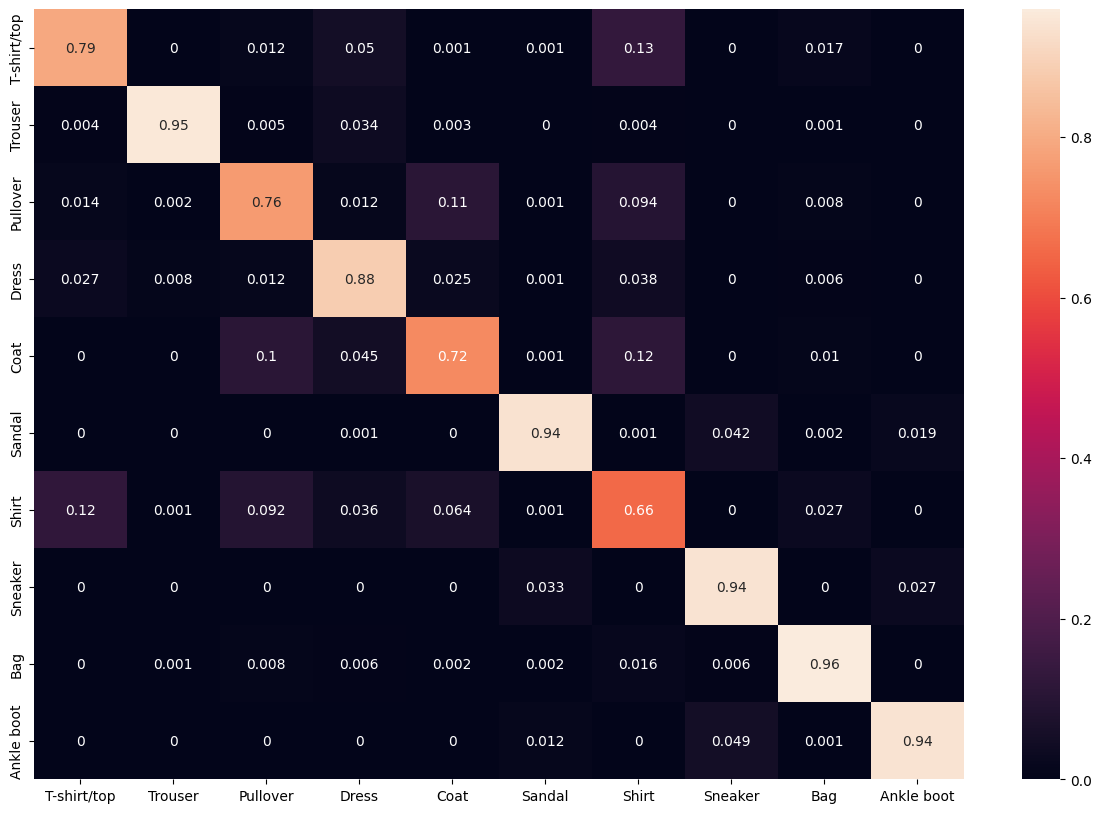

In [100]:
from sklearn.metrics import confusion_matrix

# Calculamos la matriz comparando las etiquetas reales (y_test) con las predicciones (y_pred_labels)
# normalize='true' hace que los valores sean porcentajes (de 0 a 1) por cada clase real
c_mat = confusion_matrix(y_test, y_pred_labels, normalize='true')

# Definimos el tamaño de la figura para que la matriz sea legible
plt.figure(figsize=(15,10))

# Dibujamos un mapa de calor (heatmap) usando la librería Seaborn
# annot=True: muestra los números dentro de cada celda
# xticklabels/yticklabels: pone los nombres de las prendas en los ejes en lugar de números
sns.heatmap(c_mat, annot=True, xticklabels=class_names, yticklabels=class_names)


In [101]:
# Importamos la función para generar el informe de rendimiento detallado
from sklearn.metrics import classification_report

# Imprimimos el reporte comparando las etiquetas reales con las predicciones del modelo.
# Este informe incluye:
# - Precision: ¿De todos los que predije como X, cuántos eran realmente X?
# - Recall: ¿De todos los que eran realmente X, cuántos logré detectar?
# - F1-score: La media armonizada entre precisión y recall (balance general).
# - Support: El número de muestras reales de cada clase en el set de test.
print(classification_report(y_test, y_pred_labels))


              precision    recall  f1-score   support

           0       0.83      0.79      0.81      1000
           1       0.99      0.95      0.97      1000
           2       0.77      0.76      0.76      1000
           3       0.83      0.88      0.85      1000
           4       0.78      0.72      0.75      1000
           5       0.95      0.94      0.94      1000
           6       0.62      0.66      0.64      1000
           7       0.91      0.94      0.92      1000
           8       0.93      0.96      0.94      1000
           9       0.95      0.94      0.95      1000

    accuracy                           0.85     10000
   macro avg       0.86      0.85      0.85     10000
weighted avg       0.86      0.85      0.85     10000



Finalmente, usamos el modelo entrenado para hacer una prediccion sobre una única imagen.

In [45]:
class_names[np.argmax(model_2.predict(X_test[76:78]))]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


'Trouser'